--- Завдання 1: Перші 5 рядків ---
        date  avila_adobe  firehouse_museum  chinese_american_museum  \
0 2014-01-01         6602             24778                     1581   
1 2014-02-01         5029             18976                     1785   
2 2014-03-01         8129             25231                     3229   
3 2014-04-01         2824             26989                     2129   
4 2014-05-01        10694             36883                     3676   

   america_tropical_interpretive_center  
0                                   NaN  
1                                   NaN  
2                                   NaN  
3                                   NaN  
4                                   NaN  

Розмір датасету: (90, 5)

Типи даних:
 date                                    datetime64[ns]
avila_adobe                                      int64
firehouse_museum                                 int64
chinese_american_museum                          int64
america_tropical_int

/tmp/ipykernel_3825/1671560563.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 1], x=df['date'].dt.year, y=df['chinese_american_museum'], palette='Set2')
/tmp/ipykernel_3825/1671560563.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[2, 0], x=means.index, y=means.values, palette='viridis')
/tmp/ipykernel_3825/1671560563.py:99: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2, 0].set_xticklabels(axes[2, 0].get_xticklabels(), rotation=15)


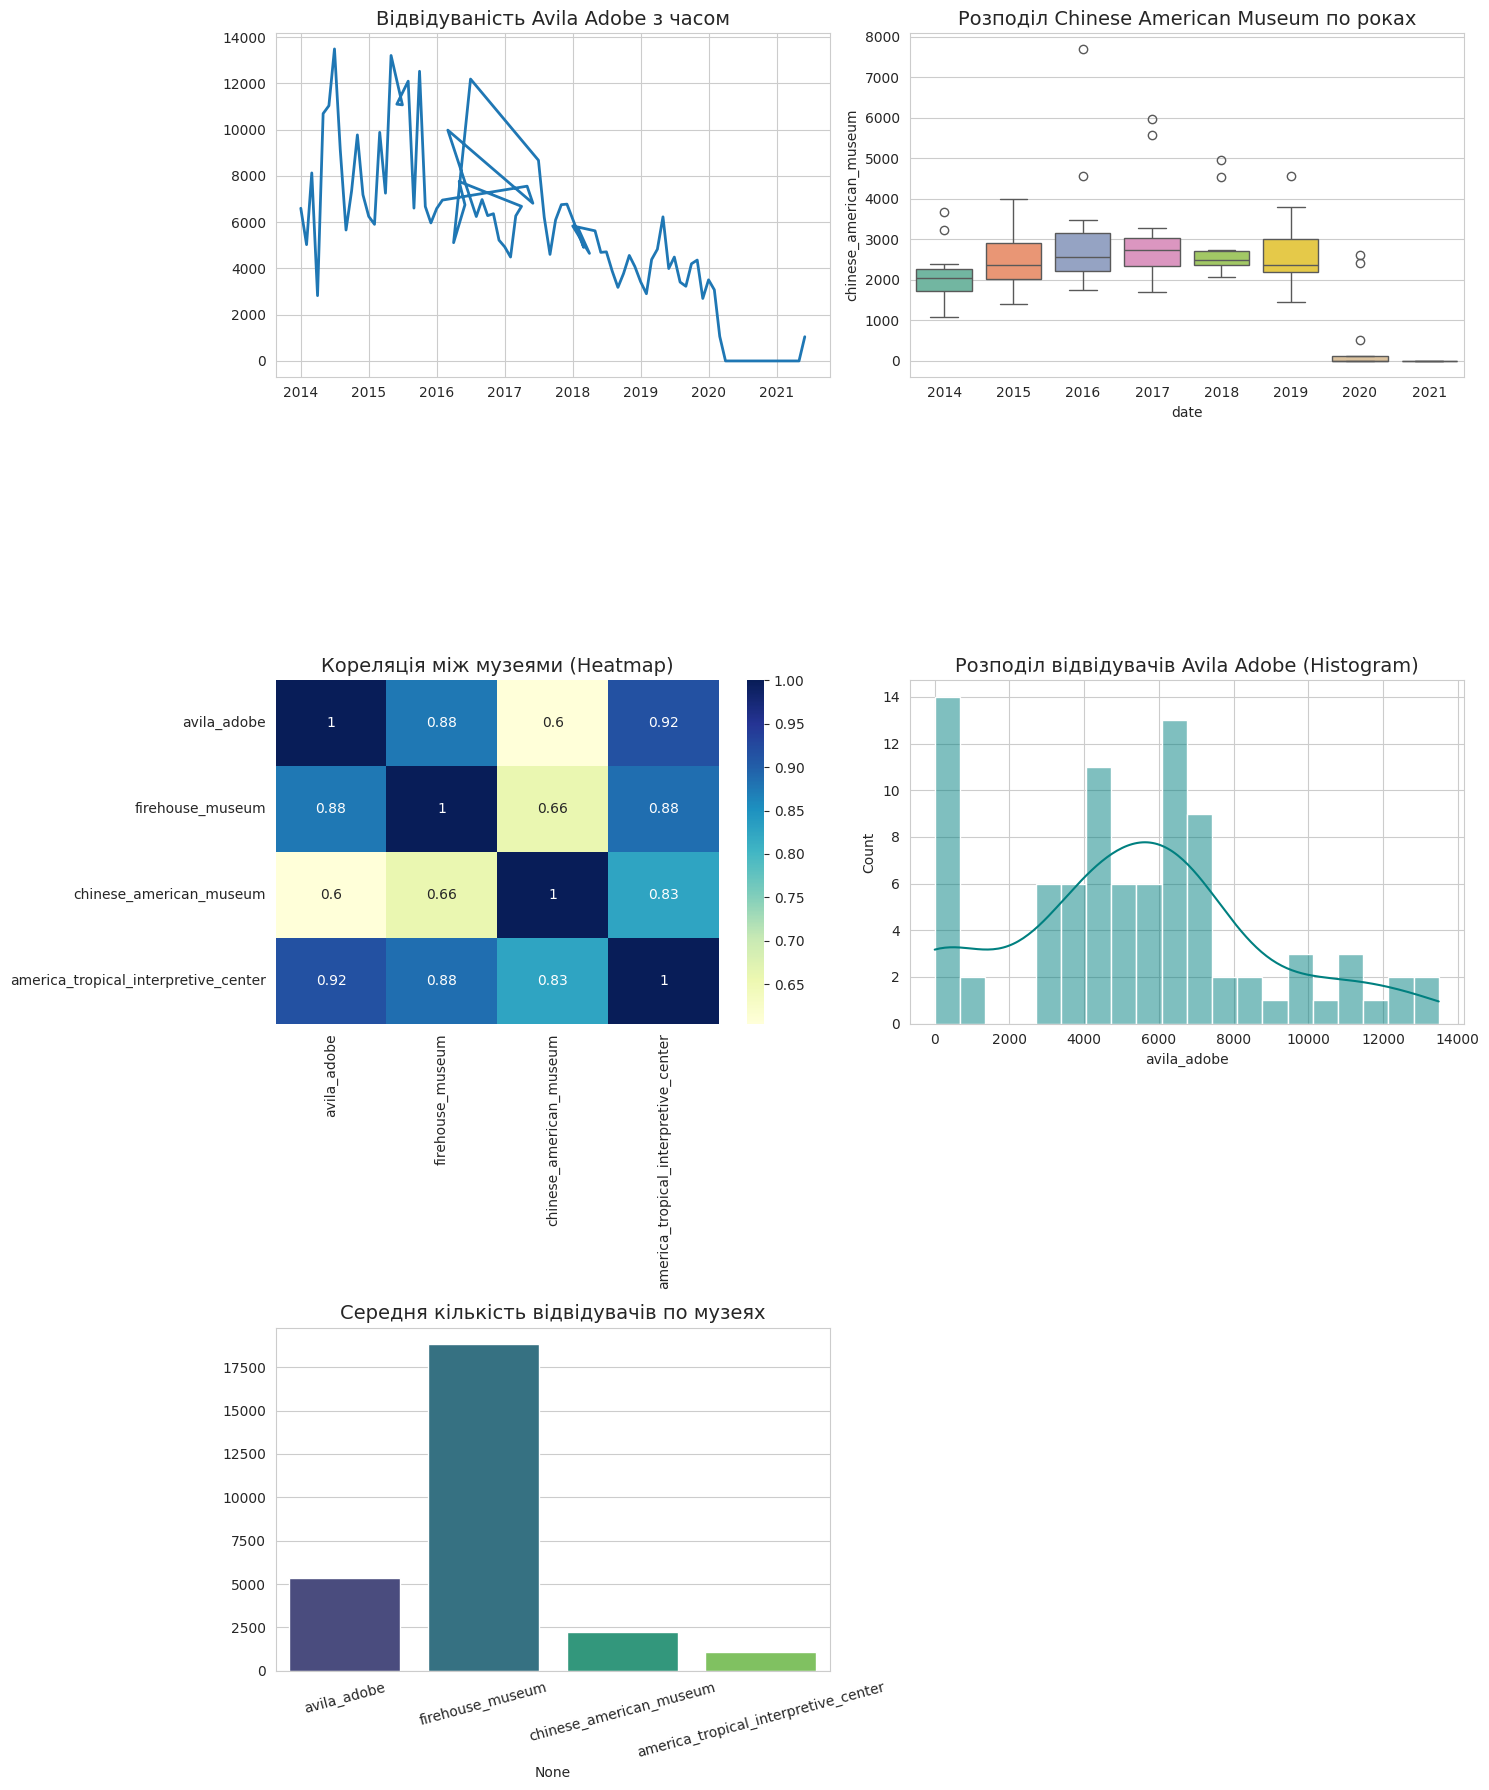

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Зчитуємо файл
df = pd.read_csv('museum-visitors.csv')

# Одразу перейменовуємо перші 5 стовпців за індексом,
df.columns.values[0] = 'date'
df.columns.values[1] = 'avila_adobe'
df.columns.values[2] = 'firehouse_museum'
df.columns.values[3] = 'chinese_american_museum'
df.columns.values[4] = 'america_tropical_interpretive_center'

# Вибираємо тільки потрібні нам стовпці для роботи
cols = ['date', 'avila_adobe', 'firehouse_museum', 'chinese_american_museum', 'america_tropical_interpretive_center']
df = df[cols].copy()

# Конвертуємо дату
df['date'] = pd.to_datetime(df['date'])

print("--- Завдання 1: Перші 5 рядків ---")
print(df.head())

# 2. АНАЛІЗ
print(f"\nРозмір датасету: {df.shape}")
print("\nТипи даних:\n", df.dtypes)
print("\nПропуски:\n", df.isna().sum())

# Видалення дублікатів
df = df.drop_duplicates()
print(f"\nРозмір після видалення дублікатів: {df.shape}")

# Роки
years = sorted(df['date'].dt.year.unique())
print(f"\nДатасет містить інформацію про роки: {years}")

# 3. ОБЧИСЛЕННЯ ТА АНАЛІЗ
# Середня кількість відвідувачів
print("\n--- Середня кількість відвідувачів ---")
print(df.drop('date', axis=1).mean())

# Min/Max за 2018 рік
df_2018 = df[df['date'].dt.year == 2018]
print("\n--- Min та Max за 2018 рік ---")
for museum in df.columns[1:]:
    print(f"{museum}: Min = {df_2018[museum].min()}, Max = {df_2018[museum].max()}")

# Найвищий та найнижчий місяці за 2015 рік
df_2015 = df[df['date'].dt.year == 2015].copy()
df_2015['total'] = df_2015.drop('date', axis=1).sum(axis=1)
max_month = df_2015.loc[df_2015['total'].idxmax(), 'date'].strftime('%B')
min_month = df_2015.loc[df_2015['total'].idxmin(), 'date'].strftime('%B')
print(f"\n2015 рік: Пік - {max_month}, Мінімум - {min_month}")

# Порівняння літо/зима 2018 (Avila Adobe)
summer = df_2018[df_2018['date'].dt.month.isin([6, 7, 8])]['avila_adobe'].sum()
winter = df_2018[df_2018['date'].dt.month.isin([12, 1, 2])]['avila_adobe'].sum()
print(f"\nAvila Adobe 2018: Літо = {summer}, Зима = {winter}")

# Кореляція 2016
print("\n--- Кореляція між музеями у 2016 році ---")
print(df[df['date'].dt.year == 2016].drop('date', axis=1).corr())

# 4. ВІЗУАЛІЗАЦІЯ
sns.set_style("whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(15, 18))

# Лінійний графік
axes[0, 0].plot(df['date'], df['avila_adobe'], color='tab:blue', linewidth=2)
axes[0, 0].set_title('Відвідуваність Avila Adobe з часом', fontsize=14)

# Boxplot
sns.boxplot(ax=axes[0, 1], x=df['date'].dt.year, y=df['chinese_american_museum'], palette='Set2')
axes[0, 1].set_title('Розподіл Chinese American Museum по роках', fontsize=14)

# Heatmap
sns.heatmap(ax=axes[1, 0], data=df.drop('date', axis=1).corr(), annot=True, cmap='YlGnBu')
axes[1, 0].set_title('Кореляція між музеями (Heatmap)', fontsize=14)

# Histogram
sns.histplot(ax=axes[1, 1], data=df['avila_adobe'], bins=20, kde=True, color='teal')
axes[1, 1].set_title('Розподіл відвідувачів Avila Adobe (Histogram)', fontsize=14)

# Barplot
means = df.drop('date', axis=1).mean()
sns.barplot(ax=axes[2, 0], x=means.index, y=means.values, palette='viridis')
axes[2, 0].set_title('Середня кількість відвідувачів по музеях', fontsize=14)
axes[2, 0].set_xticklabels(axes[2, 0].get_xticklabels(), rotation=15)

# Видаляємо порожню чарунку
fig.delaxes(axes[2, 1])
plt.tight_layout()
plt.show()

Висновки:

В ході лабораторної роботи було проведено аналіз відвідуваності музеїв Лос-Анджелеса за період 2014-2018 років.

Найпопулярнішим об'єктом є музей Avila Adobe, який стабільно має найвищу кількість відвідувачів.

Аналіз за 2015 та 2018 роки показав чітку сезонність: пік відвідуваності припадає на літні місяці, тоді як взимку кількість візитів суттєво знижується.

Побудована теплокарта кореляції показала сильний зв'язок між відвідуваністю різних музеїв. Це свідчить про те, що туристичні потоки зазвичай охоплюють кілька об'єктів одночасно.